In [ ]:
## IMPORTING
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,confusion_matrix,roc_curve, auc,precision_score,recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [3]:
df = pd.read_csv("../data/creditcard.csv")

In [4]:
X = df.drop(columns="Class")
y = df["Class"]


In [5]:
# Splitting the Training and Testing data
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,stratify=y,random_state=42)

In [17]:

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
# 
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]


print(f"Accuracy Score : {accuracy_score(y_test,y_pred)*100:.2f}")
print("--"*30)
print(f"ROC AUC Score : {roc_auc_score(y_test, y_probs)*100:.2f}")
print("--"*30)
print(f"Precision Score: {precision_score(y_test,y_pred)*100:.2f}")
print("--"*30)
print(f"Recall Score: {recall_score(y_test,y_pred)*100:.2f}")
print("--"*30)
print("Classification Report : \n")
print(classification_report(y_test, y_pred))

Accuracy Score : 99.96
------------------------------------------------------------
ROC AUC Score : 96.30
------------------------------------------------------------
Precision Score: 94.12
------------------------------------------------------------
Recall Score: 81.63
------------------------------------------------------------
Classification Report : 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



### COnfusion Matric

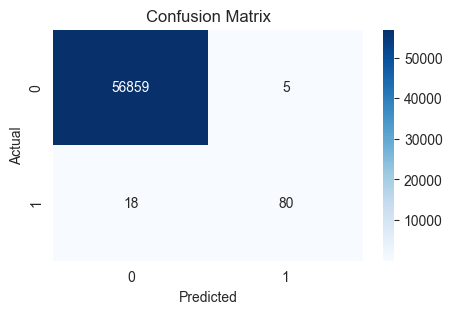

In [65]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../reports/modelpred/confusion_matrix.png")
plt.show()

### ROC-AUC Curve

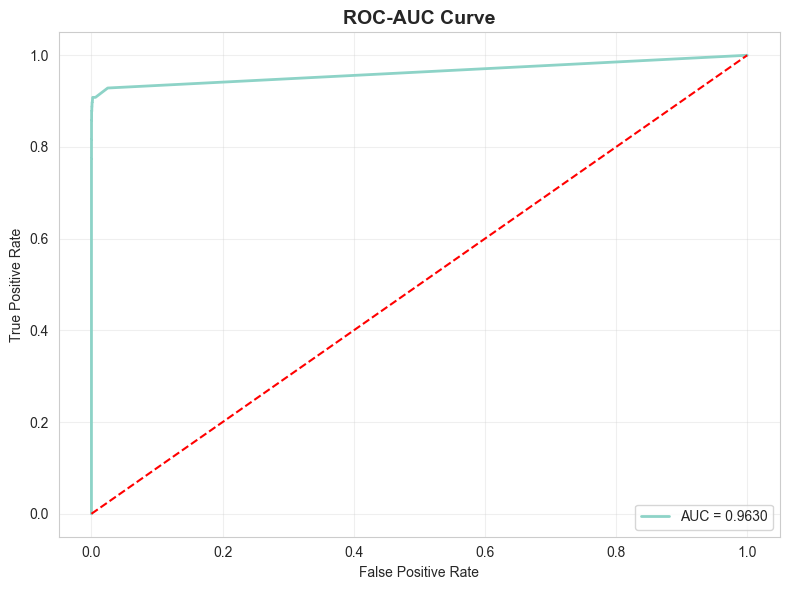

In [64]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color="red", linewidth=1.5)

plt.title("ROC-AUC Curve", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save
plt.savefig("../reports/modelpred/roc_auc_curve.png")

plt.show()

# Feature Selection

C:\Users\91706\AppData\Local\Temp\ipykernel_15716\2193381364.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


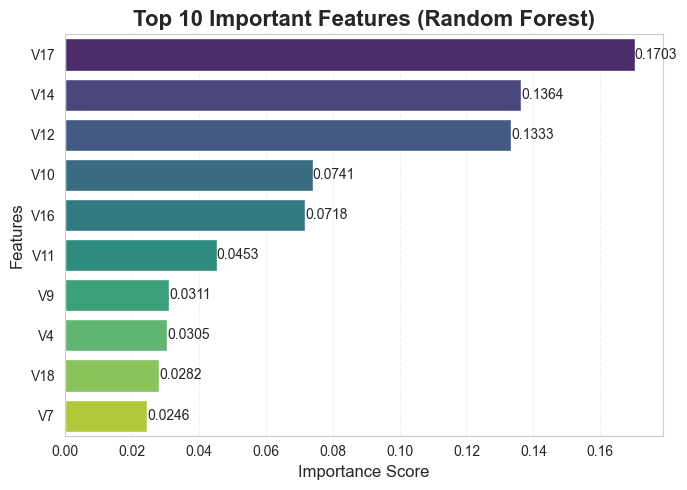

In [66]:
importance = model.feature_importances_
features = X.columns

fem = pd.Series(importance, index=features).sort_values(ascending=False).head(10)

sns.set_style("whitegrid")

plt.figure(figsize=(7,5))

colors = sns.color_palette("viridis", len(fem))

sns.barplot(
    x=fem.values,
    y=fem.index,
    palette=colors
)

# Labels
plt.title("Top 10 Important Features (Random Forest)", fontsize=16, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Add values on bars
for i, v in enumerate(fem.values):
    plt.text(v, i, f"{v:.4f}", va='center', fontsize=10)

# Clean layout
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/modelpred/imp_features.png")
plt.show()

### Saving the model 

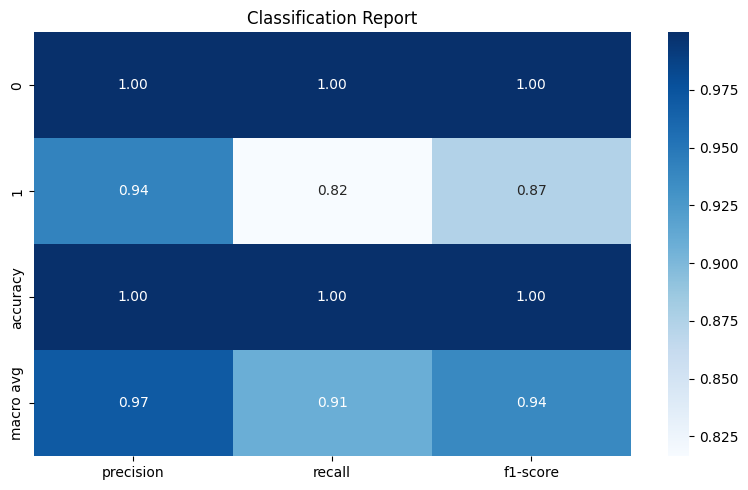

In [22]:
report = classification_report(y_test, y_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f")

plt.title("Classification Report")
plt.tight_layout()

# Save image
plt.savefig("../reports/figures/classification_report.png")
plt.savefig("../reports/modelpred/Classification_Report.png")
plt.show()

In [9]:
joblib.dump(model, "../models/model.pkl")

['../models/model.pkl']

In [ ]:
print(os.listdir("../models"))

['model.pkl']
